In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [4]:
root_path =  "C:\\Users\\Mateus\\OneDrive\\Documentos\\7.ENSTA\\3A\\CSC_5RO11-ROS\\knn\\dataset"

train_path = os.path.join(root_path, 'train')
test_path = os.path.join(root_path, 'test')

emotion_list = os.listdir(train_path)
print(emotion_list)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


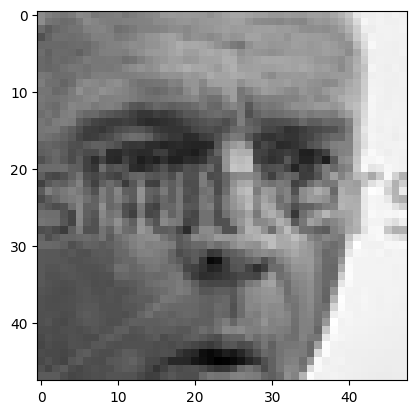

In [5]:
train_surprise_path = os.path.join(train_path, 'surprise')
img_example_name = os.listdir(train_surprise_path)[0]
img_example = plt.imread(os.path.join(train_surprise_path, img_example_name))

plt.imshow(img_example, cmap='gray')


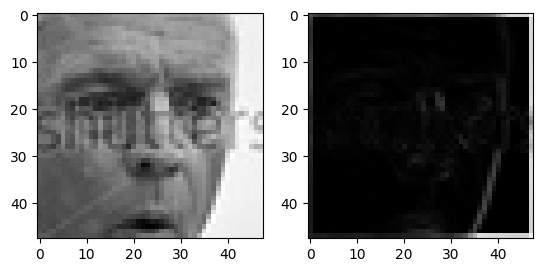

In [6]:
import skimage.feature

img_example_lbp = skimage.feature.local_binary_pattern(img_example, 8, 1.0, 'var')
plt.subplot(121)
plt.imshow(img_example, cmap='gray');
plt.subplot(122)
plt.imshow(img_example_lbp, cmap='gray');

Accuracy: 23.02%


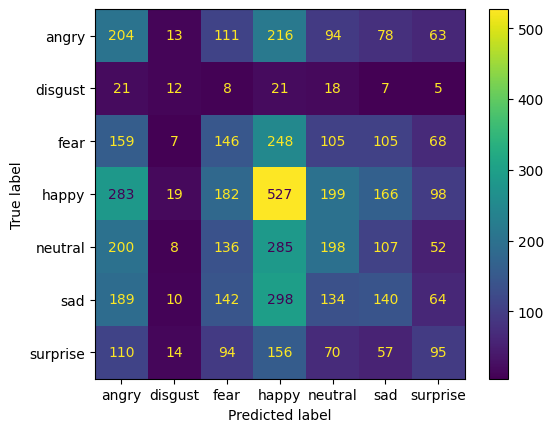

In [9]:
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Function to calculate LBP and transform the image into a feature vector
def extract_lbp_features(img):
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    hist = hist.astype('float')
    hist /= hist.sum()  # Normalize the histogram
    return hist

# Load images and labels
data, labels = [], []
for emotion_index, emotion in enumerate(emotion_list):
    emotion_path = os.path.join(train_path, emotion)
    for img_name in os.listdir(emotion_path):
        img = plt.imread(os.path.join(emotion_path, img_name))
        features = extract_lbp_features(img)
        data.append(features)
        labels.append(emotion_index)

# Convert to numpy arrays
data = np.array(data)
labels = np.array(labels)

# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, random_state=42)

# Create and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_val)

# Calculate accuracy and display the confusion matrix
accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_list)
cmd.plot(cmap='viridis')
plt.show()
